# *1. Setup & Imports*


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# *2. Data Loading & Preparation*


In [ ]:
def load_and_prepare_data(filepath: str):
    # The os.path.exists check is not needed for URLs, as pd.read_csv handles them directly.
    # If the URL is invalid or inaccessible, pd.read_csv will raise its own error.

    df = pd.read_csv(filepath)

    if df.empty:
        raise ValueError("Dataset is empty.")

    required_cols = ['price_x', 'quantity', 'cost', 'status', 'country',
                     'category', 'return_id', 'return_reason']

    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {', '.join(missing_cols)}")

    df['revenue'] = df['price_x'] * df['quantity']
    df['profit'] = df['revenue'] - (df['cost'] * df['quantity'])

    df['return_reason'] = df['return_reason'].fillna('No return')
    df['return_id'] = pd.to_numeric(df['return_id'], errors='coerce').fillna(0).astype(int)

    return df

# *3. Revenue Analysis*

In [ ]:
def print_revenue_by_category(df: pd.DataFrame):
    print("\nREVENUE BY CATEGORY")
    rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

    for cat, val in rev.items():
        print(f"{cat:<15} ${val:,.2f}")
def print_revenue_by_country(df: pd.DataFrame):
    print("\nREVENUE BY COUNTRY")

    completed_df = df[df['status'] == 'completed']
    if completed_df.empty:
        print("No completed orders.")
        return

    rev_country = completed_df.groupby('country')['revenue'].sum().sort_values(ascending=False)

    for country, val in rev_country.items():
        print(f"{country:<12} ${val:,.2f}")


# *4. Customer Behavior Analysis*

In [ ]:
def print_customer_behavior(df: pd.DataFrame):
    print("\nCUSTOMER BEHAVIOR")

    total = len(df)
    if total == 0:
        print("No data.")
        return

    completed = (df['status'] == 'completed').sum()
    abandoned = (df['status'] == 'abandoned').sum()
    cancelled = (df['status'] == 'cancelled').sum()

    print(f"Completed: {completed} ({completed/total*100:.1f}%)")
    print(f"Abandoned: {abandoned} ({abandoned/total*100:.1f}%)")
    print(f"Cancelled: {cancelled} ({cancelled/total*100:.1f}%)")

    print("\nAbandonment rate by country:")

    ab_rate = df.groupby('country')['status'].apply(
        lambda x: round((x == 'abandoned').sum() / len(x) * 100, 1)
    ).sort_values(ascending=False)

    for country, rate in ab_rate.items():
        print(f"{country:<12} {rate}%")



# *5. Returns Analysis*

In [ ]:
def print_returns_analysis(df: pd.DataFrame):
    print("\nRETURNS")

    returns = df[df['return_id'] != 0]

    if returns.empty:
        print("No returns.")
        return

    total_orders = len(df)
    total_returns = len(returns)

    print(f"Returns: {total_returns}/{total_orders} ({total_returns/total_orders*100:.1f}%)")

    print("\nReturn reasons:")
    for reason, count in returns['return_reason'].value_counts().items():
        print(f"{reason:<20} {count}")

    print("\nTop returned categories:")
    for cat, count in returns['category'].value_counts().items():
        print(f"{cat:<15} {count}")


# *6. data visualisation*




In [ ]:
def visualize_data(df: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("E-Commerce Dashboard")

    rev_cat = df.groupby('category')['revenue'].sum().sort_values()
    axes[0, 0].bar(rev_cat.index, rev_cat.values)
    axes[0, 0].set_title("Revenue by Category")

    completed = df[df['status'] == 'completed']

    if not completed.empty:
        rev_country = completed.groupby('country')['revenue'].sum()
        axes[0, 1].bar(rev_country.index, rev_country.values)
        axes[0, 1].set_title("Revenue by Country")

    status_counts = df['status'].value_counts()
    axes[1, 0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%')
    axes[1, 0].set_title("Order Status")

    returns = df[df['return_id'] != 0]
    if not returns.empty:
        reason_counts = returns['return_reason'].value_counts()
        axes[1, 1].barh(reason_counts.index, reason_counts.values)
        axes[1, 1].set_title("Return Reasons")

    plt.show()

# *6. main*




Loading data...

E-COMMERCE REPORT

Generating charts...


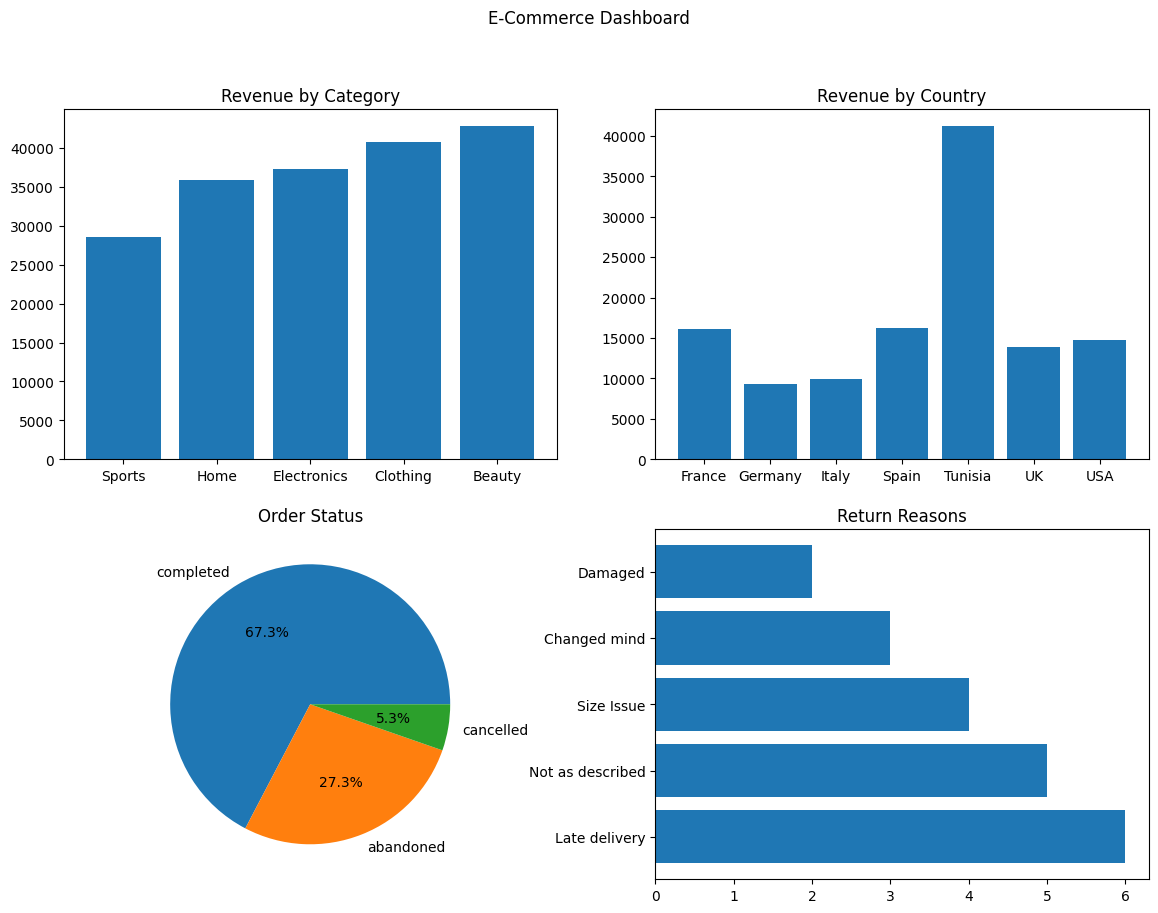

In [ ]:
def main():


  print("Loading data...")
  url = "https://raw.githubusercontent.com/iyedferjeoui/Ecommerce-Analysis-with-Pandas/Ecommerce-Analysis-with-charts/ecommerce_small_300.csv"
  df = load_and_prepare_data(url)

  print("\nE-COMMERCE REPORT")

  # Removed print_revenue_by_category(df)
  # Removed print_revenue_by_country(df)
  # Removed print_customer_behavior(df)
  # Removed print_returns_analysis(df)

  print("\nGenerating charts...")
  visualize_data(df)




if __name__ == "__main__":
    main()